# Total Cost of Ownership Analysis for Electric, CNG and Diesel Commercial Vehicles

### A Scenario-Based Economic Analysis for Fleet Electrification

This project evaluates the economic feasibility of electric vehicle (EV) adoption for commercial vehicle applications by comparing the five-year Total Cost of Ownership (TCO) of EV, CNG and diesel alternatives.

The analysis incorporates:

- Vehicle purchase cost
- Energy/fuel consumption
- Annual operating cost
- Five-year TCO
- Annual vehicle utilization
- EV purchase-price sensitivity
- Energy-price sensitivity
- Charging infrastructure cost
- Break-even utilization
- Payback period
- Fleet-scale economics
- Operating scenarios

**Tools:** Python, Pandas, NumPy, Matplotlib

**Analysis Type:** Techno-economic / Fleet Economics / Sensitivity Analysis

## Methodology

The analysis follows a Total Cost of Ownership framework.

### Total Cost of Ownership

The five-year TCO is calculated as:

**5-Year TCO = Purchase Cost + 5-Year Energy Cost + Other Applicable Costs**

For each vehicle technology, annual energy cost is estimated from:

**Annual Energy Cost = Annual Utilization × Energy Consumption per km × Energy/Fuel Price**

The resulting annual operating cost is then projected over the five-year analysis period.

### Comparative Analysis

The EV is compared against CNG and diesel alternatives under a common annual utilization assumption.

Sensitivity analysis is subsequently performed by varying:

1. Annual utilization
2. EV purchase price
3. Energy/fuel prices
4. Charging infrastructure cost

Additional analysis includes break-even utilization, simple payback period and fleet-scale economics.

## Key Assumptions

The analysis is based on the following assumptions:

- Analysis period: 5 years
- Baseline annual utilization: 25,000 km/year
- Vehicle utilization is assumed to remain constant over the analysis period.
- Energy/fuel consumption is assumed to remain constant.
- Energy/fuel prices are treated according to the defined baseline values.
- Vehicle purchase prices are expressed in ₹ lakh.
- TCO values are converted and reported in ₹ lakh for comparison.
- The model uses the defined vehicle specifications and operating assumptions.
- Charging infrastructure costs are evaluated separately through sensitivity analysis.
- Payload is included as a vehicle parameter; the current TCO formulation does not explicitly model a payload-dependent change in energy consumption.
- Financing costs, insurance, taxation, resale value and unexpected maintenance costs are excluded unless explicitly incorporated into the model.
- Results are therefore scenario-based estimates rather than guaranteed future costs.

# EV Fleet Transition: TCO & Strategic Decision Analysis

### Consulting-Oriented Energy Transition Case Study

**Objective:**  
Evaluate whether a commercial vehicle fleet should transition from
conventional CNG vehicles to electric vehicles using Total Cost of
Ownership (TCO), sensitivity analysis, and fleet-level decision rules.

### Key Business Questions

1. When does an EV become economically preferable to CNG?
2. How sensitive is the decision to electricity prices and vehicle efficiency?
3. How much charging infrastructure investment can the EV economically support?
4. Which fleet profiles should be electrified first?
5. Which vehicles should be piloted or retained on CNG?

### Analysis Horizon
5 years


# 2. Model Assumptions


These values are illustrative and should be replaced with
client-specific data in a real consulting engagement.

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



ANALYSIS_YEARS = 5

# Base annual vehicle utilization
BASE_ANNUAL_KM = 25_000

# Sensitivity-analysis ranges
UTILIZATION_SCENARIOS = np.arange(
    5_000,
    60_001,
    5_000
)

ELECTRICITY_PRICE_SCENARIOS = np.arange(
    4.5,
    20.1,
    1.0
)

EV_EFFICIENCY_SCENARIOS = np.arange(
    8,
    24.1,
    1.0
)

INFRASTRUCTURE_SCENARIOS = np.arange(
    0,
    500_001,
    25_000
)

# 3. Input Data

The analysis compares representative commercial vehicles across
three fuel technologies:

- Battery Electric Vehicle (EV)
- CNG
- Diesel

The input data includes vehicle acquisition cost, payload,
energy consumption, energy price, and fuel type.

In [92]:

vehicles = pd.DataFrame({
    "vehicle": [
        "Tata Ace Pro EV",
        "Tata Ace Pro Bi-Fuel",
        "Tata Ace Gold Diesel"
    ],

    "fuel_type": [
        "Electric",
        "CNG",
        "Diesel"
    ],

    "purchase_price_lakh": [
        6.50,
        4.99,
        5.99
    ],

    "payload_kg": [
        750,
        750,
        900
    ],

    "energy_consumption": [
        0.120000,
        0.047619,
        0.045455
    ],

    "energy_unit": [
        "kWh/km",
        "kg/km",
        "litre/km"
    ]
})

vehicles

,vehicle,fuel_type,purchase_price_lakh,payload_kg,energy_consumption,energy_unit
0,Tata Ace Pro EV,Electric,6.50,750,0.120000,kWh/km
1,Tata Ace Pro Bi-Fuel,CNG,4.99,750,0.047619,kg/km
2,Tata Ace Gold Diesel,Diesel,5.99,900,0.045455,litre/km


In [93]:

# ENERGY PRICE ASSUMPTIONS

energy_prices = {
    "Electric": 4.50,
    "CNG": 83.09,
    "Diesel": 95.20
}

# Map the appropriate energy price to each vehicle
vehicles["energy_price"] = (
    vehicles["fuel_type"].map(energy_prices)
)

vehicles

,vehicle,fuel_type,purchase_price_lakh,payload_kg,energy_consumption,energy_unit,energy_price
0,Tata Ace Pro EV,Electric,6.50,750,0.120000,kWh/km,4.50
1,Tata Ace Pro Bi-Fuel,CNG,4.99,750,0.047619,kg/km,83.09
2,Tata Ace Gold Diesel,Diesel,5.99,900,0.045455,litre/km,95.20


## 3.1 TCO Assumptions

The TCO model incorporates:

- Purchase price
- Annual energy cost
- Maintenance
- Insurance
- Residual value


In [94]:

# TCO ASSUMPTIONS

# Annual non-energy operating costs include maintenance,
# insurance, and other recurring operating expenses.
tco_assumptions = {
    "annual_non_energy_operating_cost": {
        "Electric": 36_000,
        "CNG": 48_000,
        "Diesel": 53_000
    },


    

    "residual_value_percent": {
        "Electric": 12.3077,
        "CNG": 15.0,
        "Diesel": 15.0
    }
}

In [95]:

#  CALCULATE ENERGY COST PER KILOMETRE

def calculate_energy_cost_per_km(vehicle_row):
    """
    

    Formula:
        Energy Cost/km = Energy Consumption × Energy Price


    """

    return (
        vehicle_row["energy_consumption"]
        * vehicle_row["energy_price"]
    )

In [96]:

# CALCULATE FIVE-YEAR TOTAL COST OF OWNERSHIP

def calculate_tco(vehicle_row, annual_km):
    """
    Calculate the five-year Total Cost of Ownership (TCO).

    TCO includes:
        1. Vehicle purchase cost
        2. Energy/fuel cost
        3. Other annual operating costs
        4. Residual value deduction


    """

     #1. Vehicle purchase cost
    

    purchase_price = (
        vehicle_row["purchase_price_lakh"] * 100_000
    )

    
    # 2. Annual energy/fuel cost
    

    annual_energy_cost = (
        annual_km
        * vehicle_row["energy_cost_per_km"]
    )

    
    # 3. Other annual operating costs
    
    annual_non_energy_cost = (
        tco_assumptions[
            "annual_non_energy_operating_cost"
        ][vehicle_row["fuel_type"]]
    )

    
    # 4. Residual value after five years
    

    residual_percent = (
        tco_assumptions[
            "residual_value_percent"
        ][vehicle_row["fuel_type"]]
    )

    residual_value = (
        purchase_price
        * residual_percent
        / 100
    )

    
    # 5. Total five-year TCO
    

    total_tco = (
        purchase_price
        + ANALYSIS_YEARS * (
            annual_energy_cost
            + annual_non_energy_cost
        )
        - residual_value
    )

    return total_tco

In [97]:
# TCO INCLUDING CHARGING INFRASTRUCTURE

def calculate_tco_with_infrastructure(
    vehicle_row,
    annual_km,
    infrastructure_cost
):
    

    # Calculate the base five-year TCO
    base_tco = calculate_tco(
        vehicle_row,
        annual_km
    )

    # Add charging infrastructure investment
    total_tco = (
        base_tco
        + infrastructure_cost
    )

    return total_tco

# 5. Data Preparation

Before performing the TCO analysis, the raw vehicle inputs are
transformed into comparable operating-cost metrics.

The main calculated metric is:

**Energy Cost per km = Energy Consumption × Energy Price**

This allows vehicles using different energy sources—electricity,
CNG, and diesel—to be compared on a common monetary basis.

In [98]:
# ============================================================
# CALCULATE ENERGY COST PER KILOMETRE

vehicles["energy_cost_per_km"] = vehicles.apply(
    calculate_energy_cost_per_km,
    axis=1
)


vehicles[
    [
        "vehicle",
        "fuel_type",
        "energy_consumption",
        "energy_price",
        "energy_cost_per_km"
    ]
]

,vehicle,fuel_type,energy_consumption,energy_price,energy_cost_per_km
0,Tata Ace Pro EV,Electric,0.120000,4.50,0.540000
1,Tata Ace Pro Bi-Fuel,CNG,0.047619,83.09,3.956663
2,Tata Ace Gold Diesel,Diesel,0.045455,95.20,4.327316


## 5.2 Annual Energy Cost

Annual energy cost is calculated using the base annual utilization
assumption of 25,000 km.

This represents the direct energy/fuel expenditure before accounting
for maintenance, insurance, or vehicle acquisition costs.

In [99]:
# CALCULATE ANNUAL ENERGY COST


# Annual energy cost = Annual distance × Energy cost per km

vehicles["annual_energy_cost"] = (
    BASE_ANNUAL_KM
    * vehicles["energy_cost_per_km"]
)

# Display annual energy expenditure for each vehicle
vehicles[
    [
        "vehicle",
        "fuel_type",
        "annual_energy_cost"
    ]
]

,vehicle,fuel_type,annual_energy_cost
0,Tata Ace Pro EV,Electric,13500.00000
1,Tata Ace Pro Bi-Fuel,CNG,98916.56775
2,Tata Ace Gold Diesel,Diesel,108182.90000


## 5.3 Baseline Five-Year TCO

The baseline TCO represents the five-year ownership cost at the
base utilization of 25,000 km/year.

It combines:

- Vehicle purchase cost
- Energy/fuel expenditure
- Maintenance
- Insurance
- Residual value

In [100]:
# ============================================================
# CALCULATE BASELINE FIVE-YEAR TCO
# ============================================================

# Calculate five-year TCO for each vehicle at the
# base annual utilization.

vehicles["five_year_tco"] = vehicles.apply(
    lambda row: calculate_tco(
        row,
        BASE_ANNUAL_KM
    ),
    axis=1
)

# Convert TCO from ₹ to ₹ lakh for easier interpretation
vehicles["five_year_tco_lakh"] = (
    vehicles["five_year_tco"] / 100_000
)

vehicles[
    [
        "vehicle",
        "purchase_price_lakh",
        "annual_energy_cost",
        "five_year_tco_lakh"
    ]
]

,vehicle,purchase_price_lakh,annual_energy_cost,five_year_tco_lakh
0,Tata Ace Pro EV,6.50,13500.00000,8.175000
1,Tata Ace Pro Bi-Fuel,4.99,98916.56775,11.587328
2,Tata Ace Gold Diesel,5.99,108182.90000,13.150645


## 5.4 Baseline Vehicle Comparison

The following table summarizes the key economic metrics used in the
subsequent analysis.

In [101]:
# ============================================================
# BASELINE VEHICLE COMPARISON
# ============================================================

baseline_comparison = vehicles[
    [
        "vehicle",
        "fuel_type",
        "purchase_price_lakh",
        "payload_kg",
        "energy_cost_per_km",
        "annual_energy_cost",
        "five_year_tco_lakh"
    ]
].copy()

baseline_comparison

,vehicle,fuel_type,purchase_price_lakh,payload_kg,energy_cost_per_km,annual_energy_cost,five_year_tco_lakh
0,Tata Ace Pro EV,Electric,6.50,750,0.540000,13500.00000,8.175000
1,Tata Ace Pro Bi-Fuel,CNG,4.99,750,3.956663,98916.56775,11.587328
2,Tata Ace Gold Diesel,Diesel,5.99,900,4.327316,108182.90000,13.150645


# 6. Baseline Vehicle Economics

The baseline comparison evaluates the three vehicle technologies under
a common annual utilization of 25,000 km.

The objective is to establish the initial economic position of each
technology before testing how the decision changes under different
operating conditions.

### Decision Metric

The primary metric is **five-year Total Cost of Ownership (TCO)**.

A lower TCO indicates a lower total ownership cost over the analysis
period.

## 6.1 Five-Year TCO Comparison

The chart below compares the five-year TCO of the EV, CNG, and diesel
alternatives at the base utilization level.

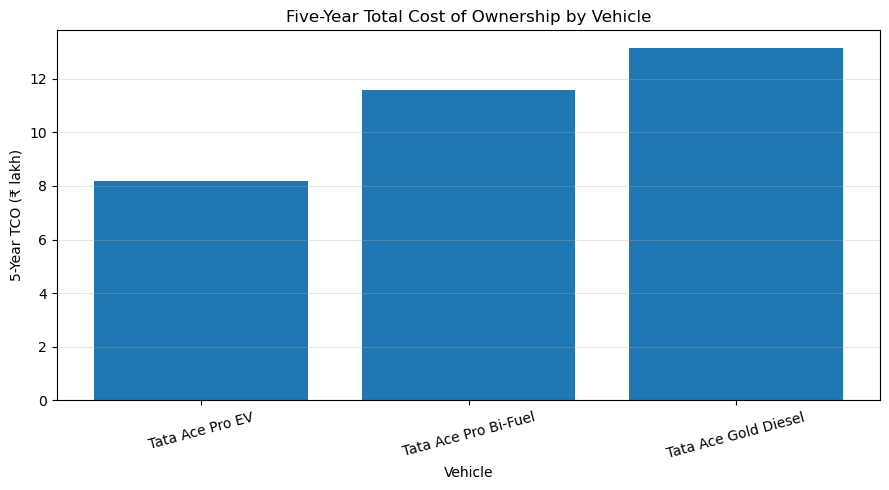

In [102]:
# ============================================================
# BASELINE TCO COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    baseline_comparison["vehicle"],
    baseline_comparison["five_year_tco_lakh"]
)

plt.ylabel("5-Year TCO (₹ lakh)")
plt.xlabel("Vehicle")
plt.title(
    "Five-Year Total Cost of Ownership by Vehicle"
)

plt.xticks(rotation=15)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 6.2 Economic Advantage of EV

The economic advantage of EV is measured relative to each conventional
alternative.

This converts the model output into a business-relevant metric:
**potential cost savings over five years.**

In [103]:
# ============================================================
# CALCULATE FIVE-YEAR SAVINGS FROM EV
# ============================================================

ev_tco = baseline_comparison.loc[
    baseline_comparison["fuel_type"] == "Electric",
    "five_year_tco_lakh"
].iloc[0]

cng_tco = baseline_comparison.loc[
    baseline_comparison["fuel_type"] == "CNG",
    "five_year_tco_lakh"
].iloc[0]

diesel_tco = baseline_comparison.loc[
    baseline_comparison["fuel_type"] == "Diesel",
    "five_year_tco_lakh"
].iloc[0]

ev_savings_vs_cng = cng_tco - ev_tco
ev_savings_vs_diesel = diesel_tco - ev_tco

print(
    f"EV savings vs CNG: ₹{ev_savings_vs_cng:.2f} lakh"
)

print(
    f"EV savings vs Diesel: ₹{ev_savings_vs_diesel:.2f} lakh"
)

EV savings vs CNG: ₹3.41 lakh
EV savings vs Diesel: ₹4.98 lakh


## 7.1 Utilization Scenarios

We evaluate annual vehicle utilization from 5,000 to 60,000 km/year.

This range represents low-use through high-use commercial fleet
applications.

In [104]:
# ============================================================
# UTILIZATION SCENARIOS
# ============================================================

# Annual distance scenarios used to test how utilization
# affects the five-year TCO of each vehicle.

utilization_scenarios = np.arange(
    5_000,
    60_001,
    5_000
)

utilization_scenarios

array([ 5000, 10000, 15000, 20000, 25000, 30000, 35000, 40000, 45000,
       50000, 55000, 60000])

## 7.2 TCO Across Utilization Levels

For each utilization scenario, the five-year TCO is recalculated.

All other assumptions remain constant so that the effect of utilization
can be isolated.

In [105]:
# ============================================================
# TCO SENSITIVITY TO ANNUAL UTILIZATION
# ============================================================

utilization_results = []

# Calculate TCO for every vehicle at every utilization level.
for annual_km in utilization_scenarios:

    for _, vehicle_row in vehicles.iterrows():

        tco = calculate_tco(
            vehicle_row,
            annual_km
        )

        utilization_results.append({
            "annual_km": annual_km,
            "vehicle": vehicle_row["vehicle"],
            "fuel_type": vehicle_row["fuel_type"],
            "five_year_tco_lakh": tco / 100_000
        })

utilization_df = pd.DataFrame(
    utilization_results
)

utilization_df.head()

,annual_km,vehicle,fuel_type,five_year_tco_lakh
0,5000,Tata Ace Pro EV,Electric,7.634999
1,5000,Tata Ace Pro Bi-Fuel,CNG,7.630666
2,5000,Tata Ace Gold Diesel,Diesel,8.823329
3,10000,Tata Ace Pro EV,Electric,7.769999
4,10000,Tata Ace Pro Bi-Fuel,CNG,8.619831


In [106]:
utilization_df

,annual_km,vehicle,fuel_type,five_year_tco_lakh
0,5000,Tata Ace Pro EV,Electric,7.634999
1,5000,Tata Ace Pro Bi-Fuel,CNG,7.630666
2,5000,Tata Ace Gold Diesel,Diesel,8.823329
3,10000,Tata Ace Pro EV,Electric,7.769999
4,10000,Tata Ace Pro Bi-Fuel,CNG,8.619831
5,10000,Tata Ace Gold Diesel,Diesel,9.905158
6,15000,Tata Ace Pro EV,Electric,7.904999
7,15000,Tata Ace Pro Bi-Fuel,CNG,9.608997
8,15000,Tata Ace Gold Diesel,Diesel,10.986987
9,20000,Tata Ace Pro EV,Electric,8.040000


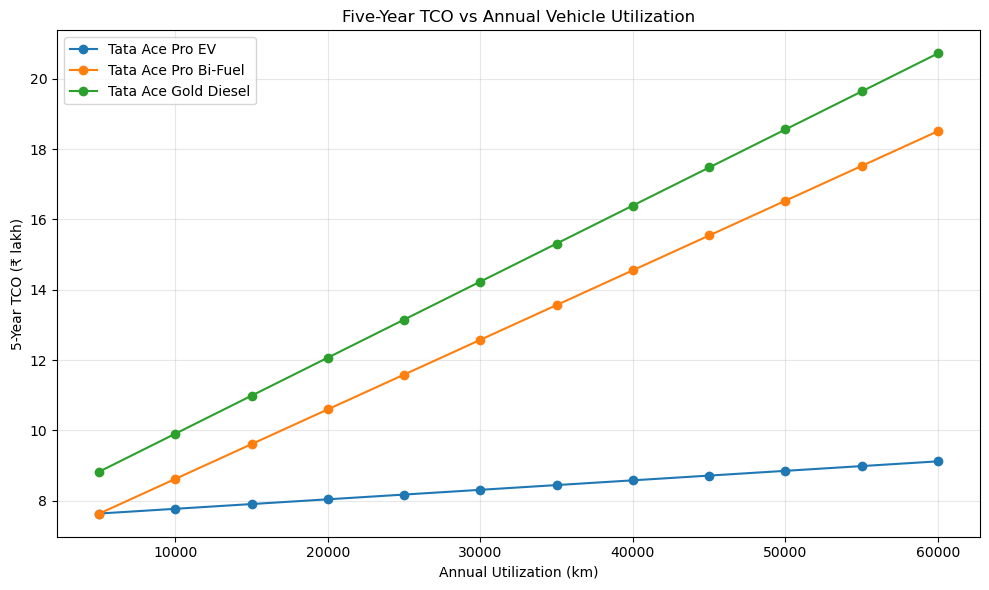

In [107]:


# PLOT TCO VS ANNUAL UTILIZATION


plt.figure(figsize=(10, 6))

for vehicle in utilization_df["vehicle"].unique():

    vehicle_data = utilization_df[
        utilization_df["vehicle"] == vehicle
    ]

    plt.plot(
        vehicle_data["annual_km"],
        vehicle_data["five_year_tco_lakh"],
        marker="o",
        label=vehicle
    )

plt.xlabel("Annual Utilization (km)")
plt.ylabel("5-Year TCO (₹ lakh)")
plt.title(
    "Five-Year TCO vs Annual Vehicle Utilization"
)

plt.legend()
plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 7.4 Utilization Break-Even

The break-even utilization represents the annual distance at which
the five-year TCO of EV becomes equal to the TCO of a conventional
alternative.

Above this threshold, EV provides the lower TCO under the model
assumptions.

Below this threshold, the conventional vehicle has the lower TCO.

In [108]:
# ============================================================
# TRUE UTILIZATION BREAK-EVEN FUNCTION
# ============================================================

def find_utilization_break_even(
    vehicle_a,
    vehicle_b,
    max_km=100_000
):
    """
    Find the annual utilization level at which the TCO
    of two vehicles crosses over.

    A break-even point exists only when the TCO difference
    changes sign.

    Returns:
        Break-even utilization in km/year, or None if
        no crossover occurs within the specified range.
    """

    # Calculate TCO difference at zero utilization.
    previous_difference = (
        calculate_tco(vehicle_a, 0)
        - calculate_tco(vehicle_b, 0)
    )

    # Check utilization one kilometre at a time.
    for annual_km in range(1, max_km + 1):

        current_difference = (
            calculate_tco(vehicle_a, annual_km)
            - calculate_tco(vehicle_b, annual_km)
        )

        # A sign change indicates that the two TCO curves
        # have crossed each other.
        if previous_difference * current_difference <= 0:

            return annual_km

        previous_difference = current_difference

    # No crossover found within the search range.
    return None

In [109]:
# ============================================================
# SELECT VEHICLES FOR BREAK-EVEN ANALYSIS
# ============================================================

ev = vehicles[
    vehicles["fuel_type"] == "Electric"
].iloc[0]

cng = vehicles[
    vehicles["fuel_type"] == "CNG"
].iloc[0]

diesel = vehicles[
    vehicles["fuel_type"] == "Diesel"
].iloc[0]

In [110]:
# ============================================================
# CALCULATE UTILIZATION BREAK-EVEN
# ============================================================

ev_vs_cng_break_even = find_utilization_break_even(
    ev,
    cng
)

ev_vs_diesel_break_even = find_utilization_break_even(
    ev,
    diesel
)

print(
    "EV vs CNG break-even:",
    ev_vs_cng_break_even,
    "km/year"
)

print(
    "EV vs Diesel break-even:",
    ev_vs_diesel_break_even,
    "km/year"
)

EV vs CNG break-even: 5026 km/year
EV vs Diesel break-even: None km/year


In [111]:
# ---------------------------------------------------------
# Overall Economic Summary
# ---------------------------------------------------------

# Extract baseline TCO values
ev_tco = ev["five_year_tco_lakh"]
cng_tco = cng["five_year_tco_lakh"]
diesel_tco = diesel["five_year_tco_lakh"]

# Calculate EV savings
ev_savings_vs_cng = cng_tco - ev_tco
ev_savings_vs_diesel = diesel_tco - ev_tco

# Create a summary table
economic_summary = pd.DataFrame({
    "Comparison": [
        "EV vs CNG",
        "EV vs Diesel"
    ],
    "EV_TCO_lakh": [
        ev_tco,
        ev_tco
    ],
    "Alternative_TCO_lakh": [
        cng_tco,
        diesel_tco
    ],
    "EV_Savings_lakh": [
        ev_savings_vs_cng,
        ev_savings_vs_diesel
    ]
})

economic_summary

,Comparison,EV_TCO_lakh,Alternative_TCO_lakh,EV_Savings_lakh
0,EV vs CNG,8.175,11.587328,3.412329
1,EV vs Diesel,8.175,13.150645,4.975646


In [112]:
# Calculate EV savings as a percentage of the alternative vehicle's TCO

economic_summary["EV_Savings_Percent"] = (
    economic_summary["EV_Savings_lakh"]
    / economic_summary["Alternative_TCO_lakh"]
) * 100

economic_summary

,Comparison,EV_TCO_lakh,Alternative_TCO_lakh,EV_Savings_lakh,EV_Savings_Percent
0,EV vs CNG,8.175,11.587328,3.412329,29.448798
1,EV vs Diesel,8.175,13.150645,4.975646,37.835753


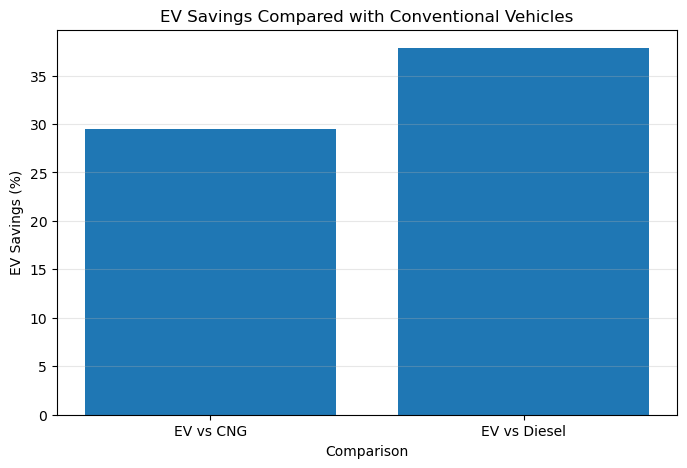

In [113]:
# Compare EV savings percentage against CNG and Diesel

plt.figure(figsize=(8, 5))

plt.bar(
    economic_summary["Comparison"],
    economic_summary["EV_Savings_Percent"]
)

plt.ylabel("EV Savings (%)")
plt.xlabel("Comparison")
plt.title("EV Savings Compared with Conventional Vehicles")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [114]:
# Identify which conventional vehicle has the lowest baseline TCO

alternative_tco = {
    "CNG": cng_tco,
    "Diesel": diesel_tco
}

lowest_cost_alternative = min(
    alternative_tco,
    key=alternative_tco.get
)

print("Lowest-cost conventional alternative:", lowest_cost_alternative)
print(
    "Its 5-year TCO:",
    round(alternative_tco[lowest_cost_alternative], 2),
    "lakh"
)

Lowest-cost conventional alternative: CNG
Its 5-year TCO: 11.59 lakh


In [115]:
# Calculate the EV payback period based on purchase price and annual energy cost

ev_purchase_price = ev["purchase_price_lakh"]
cng_purchase_price = cng["purchase_price_lakh"]
diesel_purchase_price = diesel["purchase_price_lakh"]

ev_annual_energy_cost = ev["annual_energy_cost"]
cng_annual_energy_cost = cng["annual_energy_cost"]
diesel_annual_energy_cost = diesel["annual_energy_cost"]

# Additional upfront cost of EV compared with each alternative
extra_cost_vs_cng = (ev_purchase_price - cng_purchase_price) * 100000
extra_cost_vs_diesel = (ev_purchase_price - diesel_purchase_price) * 100000

# Annual operating savings provided by EV
annual_savings_vs_cng = cng_annual_energy_cost - ev_annual_energy_cost
annual_savings_vs_diesel = diesel_annual_energy_cost - ev_annual_energy_cost

# Payback period in years
payback_vs_cng = extra_cost_vs_cng / annual_savings_vs_cng
payback_vs_diesel = extra_cost_vs_diesel / annual_savings_vs_diesel

print("EV payback vs CNG:", round(payback_vs_cng, 2), "years")
print("EV payback vs Diesel:", round(payback_vs_diesel, 2), "years")

EV payback vs CNG: 1.77 years
EV payback vs Diesel: 0.54 years


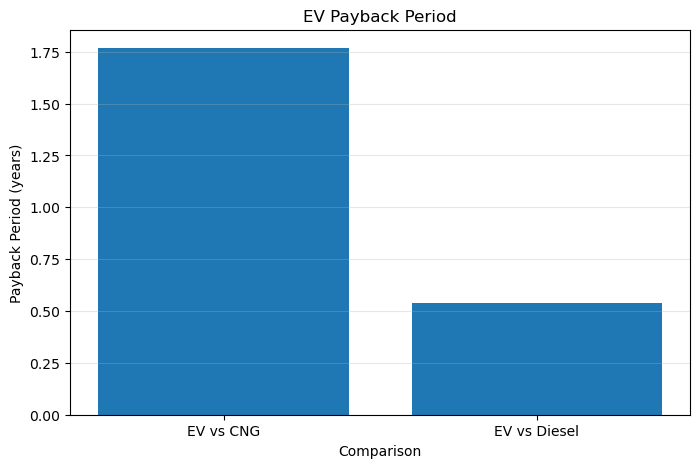

In [116]:
# Compare EV payback period against CNG and Diesel

payback_comparisons = ["EV vs CNG", "EV vs Diesel"]
payback_periods = [payback_vs_cng, payback_vs_diesel]

plt.figure(figsize=(8, 5))

plt.bar(payback_comparisons, payback_periods)

plt.ylabel("Payback Period (years)")
plt.xlabel("Comparison")
plt.title("EV Payback Period")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [117]:
# Validate the main calculated columns before finalizing the analysis

calculated_columns = [
    "energy_cost_per_km",
    "annual_energy_cost",
    "five_year_tco_lakh"
]

print("Missing values:")
print(vehicles[calculated_columns].isnull().sum())

print("\nNegative values:")
print((vehicles[calculated_columns] < 0).sum())

Missing values:
energy_cost_per_km    0
annual_energy_cost    0
five_year_tco_lakh    0
dtype: int64

Negative values:
energy_cost_per_km    0
annual_energy_cost    0
five_year_tco_lakh    0
dtype: int64


In [118]:
# ============================================================
# BASELINE UTILIZATION USED IN THE TCO ANALYSIS
# ============================================================

# Find the utilization level closest to the baseline EV TCO
baseline_idx = (
    (utilization_df["vehicle"] == ev["vehicle"]) &
    (
        abs(
            utilization_df["five_year_tco_lakh"] - ev["five_year_tco_lakh"]
        )
        == 
        abs(
            utilization_df.loc[
                utilization_df["vehicle"] == ev["vehicle"],
                "five_year_tco_lakh"
            ] - ev["five_year_tco_lakh"]
        ).min()
    )
)

baseline_utilization = utilization_df.loc[
    baseline_idx, "annual_km"
].iloc[0]

print("Baseline annual utilization:", baseline_utilization, "km/year")

Baseline annual utilization: 25000 km/year


In [119]:
# ============================================================
# SENSITIVITY OF TCO TO ANNUAL UTILIZATION
# ============================================================

utilization_levels = [
    5000, 10000, 15000, 20000,
    30000, 40000, 50000, 60000
]

sensitivity_data = []

for km in utilization_levels:

    # calculate_tco returns ₹
    # Convert to ₹ lakh by dividing by 100,000

    ev_tco = calculate_tco(ev, km) / 100000
    cng_tco = calculate_tco(cng, km) / 100000
    diesel_tco = calculate_tco(diesel, km) / 100000

    sensitivity_data.append({
        "Annual_Utilization_km": km,
        "EV_TCO_lakh": ev_tco,
        "CNG_TCO_lakh": cng_tco,
        "Diesel_TCO_lakh": diesel_tco
    })

utilization_sensitivity = pd.DataFrame(sensitivity_data)

utilization_sensitivity

,Annual_Utilization_km,EV_TCO_lakh,CNG_TCO_lakh,Diesel_TCO_lakh
0,5000,7.634999,7.630666,8.823329
1,10000,7.769999,8.619831,9.905158
2,15000,7.904999,9.608997,10.986987
3,20000,8.040000,10.598163,12.068816
4,30000,8.309999,12.576494,14.232474
5,40000,8.579999,14.554825,16.396132
6,50000,8.849999,16.533157,18.559790
7,60000,9.119999,18.511488,20.723448


In [120]:
# ============================================================
# EV SAVINGS AT DIFFERENT UTILIZATION LEVELS
# ============================================================

utilization_sensitivity["EV_Savings_vs_CNG_lakh"] = (
    utilization_sensitivity["CNG_TCO_lakh"]
    - utilization_sensitivity["EV_TCO_lakh"]
)

utilization_sensitivity["EV_Savings_vs_Diesel_lakh"] = (
    utilization_sensitivity["Diesel_TCO_lakh"]
    - utilization_sensitivity["EV_TCO_lakh"]
)

utilization_sensitivity

,Annual_Utilization_km,EV_TCO_lakh,CNG_TCO_lakh,Diesel_TCO_lakh,EV_Savings_vs_CNG_lakh,EV_Savings_vs_Diesel_lakh
0,5000,7.634999,7.630666,8.823329,-0.004334,1.188330
1,10000,7.769999,8.619831,9.905158,0.849832,2.135159
2,15000,7.904999,9.608997,10.986987,1.703998,3.081988
3,20000,8.040000,10.598163,12.068816,2.558163,4.028817
4,30000,8.309999,12.576494,14.232474,4.266495,5.922475
5,40000,8.579999,14.554825,16.396132,5.974826,7.816133
6,50000,8.849999,16.533157,18.559790,7.683157,9.709791
7,60000,9.119999,18.511488,20.723448,9.391489,11.603449


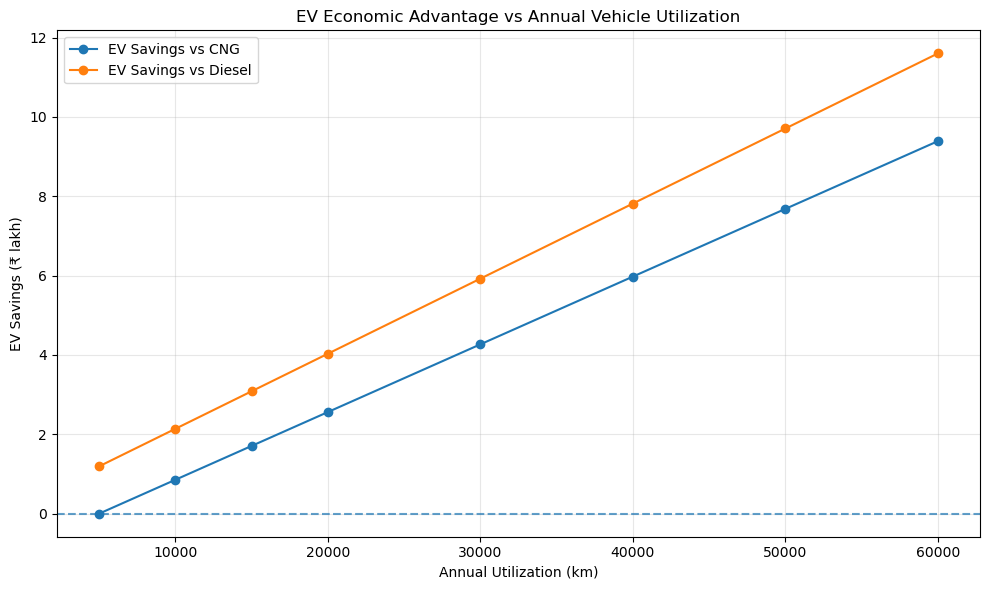

In [121]:
# ============================================================
# PLOT EV SAVINGS VS ANNUAL UTILIZATION
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    utilization_sensitivity["Annual_Utilization_km"],
    utilization_sensitivity["EV_Savings_vs_CNG_lakh"],
    marker="o",
    label="EV Savings vs CNG"
)

plt.plot(
    utilization_sensitivity["Annual_Utilization_km"],
    utilization_sensitivity["EV_Savings_vs_Diesel_lakh"],
    marker="o",
    label="EV Savings vs Diesel"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.7
)

plt.xlabel("Annual Utilization (km)")
plt.ylabel("EV Savings (₹ lakh)")
plt.title("EV Economic Advantage vs Annual Vehicle Utilization")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [122]:
# ============================================================
# EV PURCHASE PRICE SENSITIVITY
# ============================================================

purchase_price_changes = [-20, -10, 0, 10, 20]

purchase_sensitivity = []

# Baseline conventional vehicle TCO
# calculate_tco() returns ₹, so convert to ₹ lakh

baseline_cng_tco = (
    calculate_tco(cng, baseline_utilization) / 100000
)

baseline_diesel_tco = (
    calculate_tco(diesel, baseline_utilization) / 100000
)

for change in purchase_price_changes:

    # Create a copy so original EV data is not modified
    modified_ev = ev.copy()

    # Change EV purchase price
    modified_ev["purchase_price_lakh"] = (
        ev["purchase_price_lakh"]
        * (1 + change / 100)
    )

    # Calculate modified EV TCO
    # calculate_tco() returns ₹ → convert to ₹ lakh
    modified_ev_tco = (
        calculate_tco(
            modified_ev,
            baseline_utilization
        ) / 100000
    )

    purchase_sensitivity.append({
        "EV_Purchase_Price_Change_%": change,
        "EV_TCO_lakh": modified_ev_tco,
        "Savings_vs_CNG_lakh": (
            baseline_cng_tco - modified_ev_tco
        ),
        "Savings_vs_Diesel_lakh": (
            baseline_diesel_tco - modified_ev_tco
        )
    })

purchase_sensitivity = pd.DataFrame(
    purchase_sensitivity
)

purchase_sensitivity

,EV_Purchase_Price_Change_%,EV_TCO_lakh,Savings_vs_CNG_lakh,Savings_vs_Diesel_lakh
0,-20,7.035000,4.552329,6.115645
1,-10,7.605000,3.982329,5.545645
2,0,8.175000,3.412329,4.975646
3,10,8.744999,2.842329,4.405646
4,20,9.314999,2.272329,3.835646


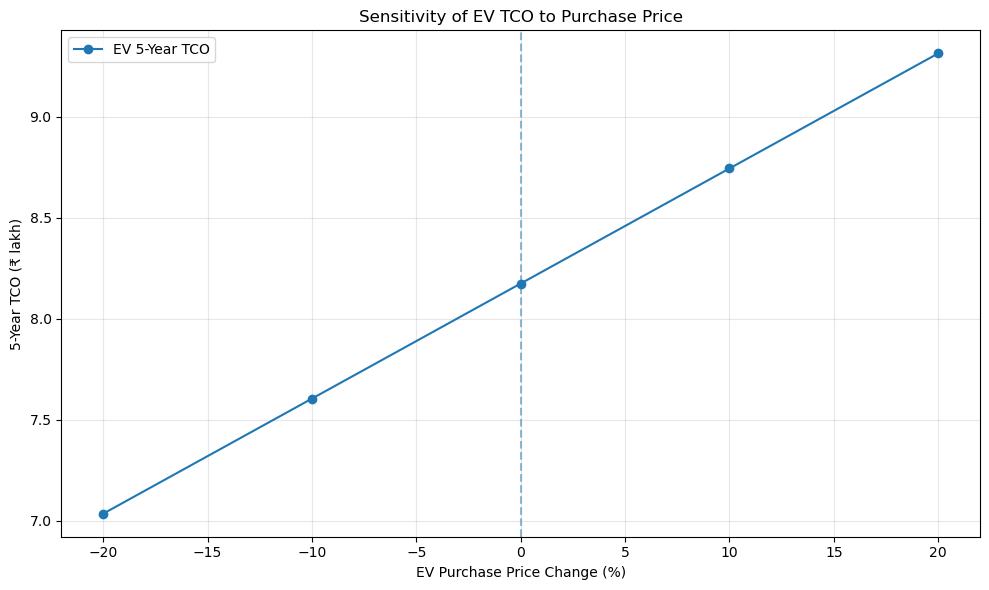

In [123]:
# ============================================================
# PLOT EV TCO VS PURCHASE PRICE CHANGE
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    purchase_sensitivity["EV_Purchase_Price_Change_%"],
    purchase_sensitivity["EV_TCO_lakh"],
    marker="o",
    label="EV 5-Year TCO"
)

plt.xlabel("EV Purchase Price Change (%)")
plt.ylabel("5-Year TCO (₹ lakh)")
plt.title("Sensitivity of EV TCO to Purchase Price")

plt.axvline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

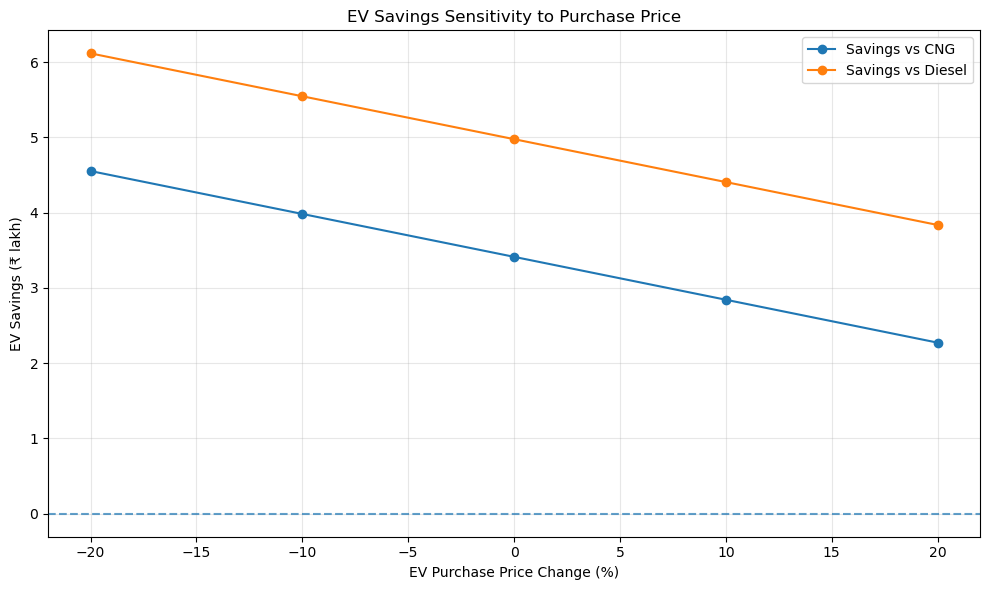

In [124]:
# ============================================================
# PLOT EV SAVINGS VS PURCHASE PRICE CHANGE
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    purchase_sensitivity["EV_Purchase_Price_Change_%"],
    purchase_sensitivity["Savings_vs_CNG_lakh"],
    marker="o",
    label="Savings vs CNG"
)

plt.plot(
    purchase_sensitivity["EV_Purchase_Price_Change_%"],
    purchase_sensitivity["Savings_vs_Diesel_lakh"],
    marker="o",
    label="Savings vs Diesel"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.7
)

plt.xlabel("EV Purchase Price Change (%)")
plt.ylabel("EV Savings (₹ lakh)")
plt.title("EV Savings Sensitivity to Purchase Price")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Energy Price Sensitivity Analysis

The total cost of ownership of each vehicle is influenced by the price of
the energy used for operation. Therefore, a sensitivity analysis is performed
to evaluate how changes in electricity, CNG, and diesel prices affect the
economic advantage of the EV.

The analysis is conducted at the baseline annual utilization of 25,000 km/year.

Energy prices are varied by ±20% while keeping all other vehicle parameters
constant. This helps evaluate the robustness of the EV's economic advantage
under different energy-price scenarios.

In [125]:
# ============================================================
# ENERGY PRICE SENSITIVITY ANALYSIS
# ============================================================

energy_price_changes = [-20, -10, 0, 10, 20]

energy_price_sensitivity = []

for change in energy_price_changes:

    # Create copies so original vehicle data remains unchanged
    modified_ev = ev.copy()
    modified_cng = cng.copy()
    modified_diesel = diesel.copy()

    # Apply the same percentage change to energy price
    modified_ev["energy_price"] = (
        ev["energy_price"] * (1 + change / 100)
    )

    modified_cng["energy_price"] = (
        cng["energy_price"] * (1 + change / 100)
    )

    modified_diesel["energy_price"] = (
        diesel["energy_price"] * (1 + change / 100)
    )

    # Calculate TCO at baseline utilization
    ev_tco = (
        calculate_tco(
            modified_ev,
            baseline_utilization
        ) / 100000
    )

    cng_tco = (
        calculate_tco(
            modified_cng,
            baseline_utilization
        ) / 100000
    )

    diesel_tco = (
        calculate_tco(
            modified_diesel,
            baseline_utilization
        ) / 100000
    )

    # Store results
    energy_price_sensitivity.append({
        "Energy_Price_Change_%": change,
        "EV_TCO_lakh": ev_tco,
        "CNG_TCO_lakh": cng_tco,
        "Diesel_TCO_lakh": diesel_tco,
        "EV_Savings_vs_CNG_lakh": cng_tco - ev_tco,
        "EV_Savings_vs_Diesel_lakh": diesel_tco - ev_tco
    })


# Convert to DataFrame
energy_price_sensitivity = pd.DataFrame(
    energy_price_sensitivity
)

energy_price_sensitivity

,Energy_Price_Change_%,EV_TCO_lakh,CNG_TCO_lakh,Diesel_TCO_lakh,EV_Savings_vs_CNG_lakh,EV_Savings_vs_Diesel_lakh
0,-20,8.175,11.587328,13.150645,3.412329,4.975646
1,-10,8.175,11.587328,13.150645,3.412329,4.975646
2,0,8.175,11.587328,13.150645,3.412329,4.975646
3,10,8.175,11.587328,13.150645,3.412329,4.975646
4,20,8.175,11.587328,13.150645,3.412329,4.975646


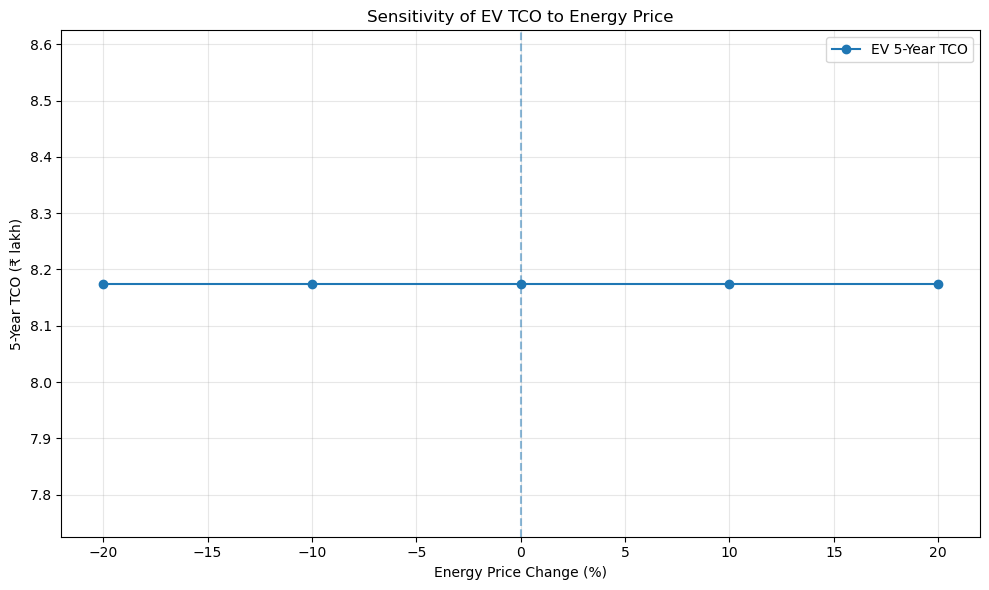

In [126]:
# ============================================================
# EV TCO SENSITIVITY TO ENERGY PRICE
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    energy_price_sensitivity["Energy_Price_Change_%"],
    energy_price_sensitivity["EV_TCO_lakh"],
    marker="o",
    label="EV 5-Year TCO"
)

plt.axvline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.xlabel("Energy Price Change (%)")
plt.ylabel("5-Year TCO (₹ lakh)")
plt.title("Sensitivity of EV TCO to Energy Price")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

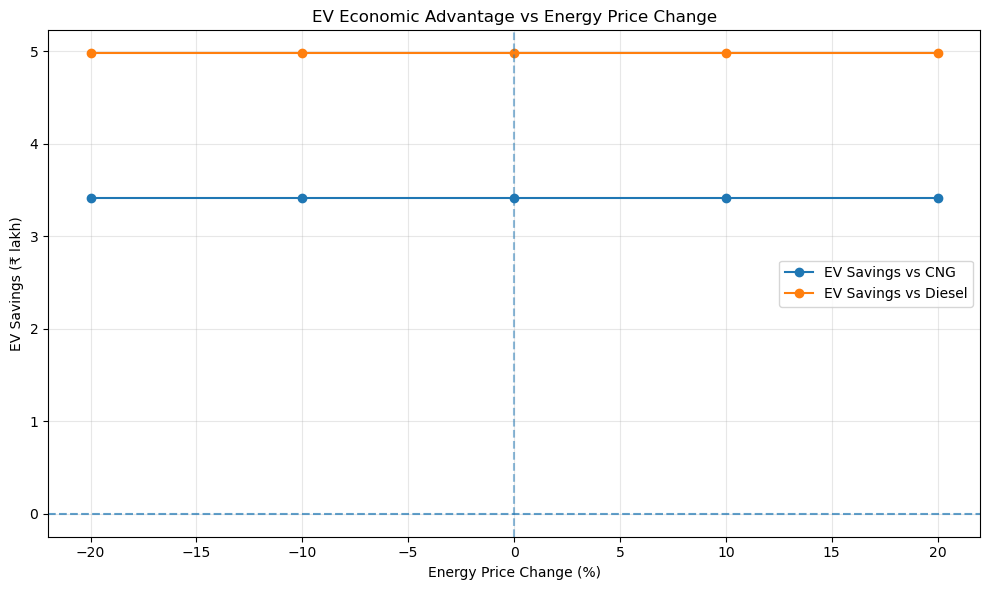

In [127]:
# ============================================================
# EV SAVINGS SENSITIVITY TO ENERGY PRICE
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    energy_price_sensitivity["Energy_Price_Change_%"],
    energy_price_sensitivity["EV_Savings_vs_CNG_lakh"],
    marker="o",
    label="EV Savings vs CNG"
)

plt.plot(
    energy_price_sensitivity["Energy_Price_Change_%"],
    energy_price_sensitivity["EV_Savings_vs_Diesel_lakh"],
    marker="o",
    label="EV Savings vs Diesel"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.7
)

plt.axvline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.xlabel("Energy Price Change (%)")
plt.ylabel("EV Savings (₹ lakh)")
plt.title("EV Economic Advantage vs Energy Price Change")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [128]:
# ============================================================
# BREAK-EVEN ANNUAL UTILIZATION
# ============================================================

# Calculate EV savings relative to CNG
utilization_sensitivity["EV_Savings_vs_CNG_lakh"] = (
    utilization_sensitivity["CNG_TCO_lakh"]
    - utilization_sensitivity["EV_TCO_lakh"]
)

# Find where EV first becomes cheaper than CNG
positive_savings = utilization_sensitivity[
    utilization_sensitivity["EV_Savings_vs_CNG_lakh"] >= 0
]

if len(positive_savings) > 0:
    first_positive = positive_savings.iloc[0]
    index = positive_savings.index[0]

    if index > 0:
        previous = utilization_sensitivity.iloc[index - 1]

        # Linear interpolation
        x1 = previous["Annual_Utilization_km"]
        y1 = previous["EV_Savings_vs_CNG_lakh"]

        x2 = first_positive["Annual_Utilization_km"]
        y2 = first_positive["EV_Savings_vs_CNG_lakh"]

        break_even_km = x1 + (0 - y1) * (x2 - x1) / (y2 - y1)

    else:
        break_even_km = first_positive["Annual_Utilization_km"]

    print(
        f"EV-CNG break-even utilization: "
        f"{break_even_km:,.0f} km/year"
    )

else:
    print("EV does not become cheaper than CNG within the tested range.")

EV-CNG break-even utilization: 5,025 km/year


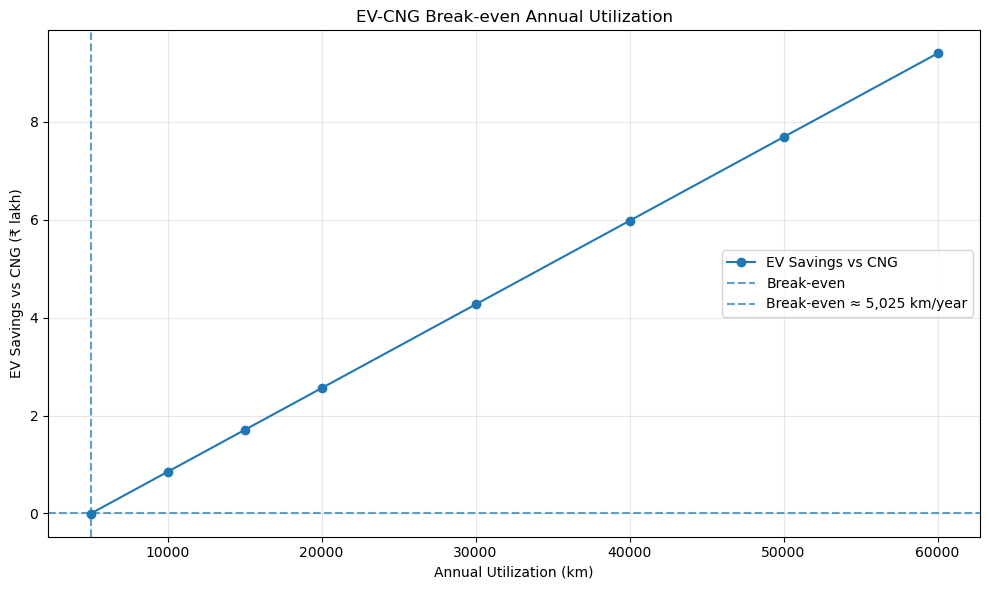

In [129]:
# ============================================================
# BREAK-EVEN UTILIZATION PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    utilization_sensitivity["Annual_Utilization_km"],
    utilization_sensitivity["EV_Savings_vs_CNG_lakh"],
    marker="o",
    label="EV Savings vs CNG"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.7,
    label="Break-even"
)

plt.axvline(
    break_even_km,
    linestyle="--",
    alpha=0.7,
    label=f"Break-even ≈ {break_even_km:,.0f} km/year"
)

plt.xlabel("Annual Utilization (km)")
plt.ylabel("EV Savings vs CNG (₹ lakh)")
plt.title("EV-CNG Break-even Annual Utilization")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [130]:
# ============================================================
# EV PAYBACK PERIOD
# ============================================================

# Purchase price difference
purchase_price_difference = (
    ev["purchase_price_lakh"] - cng["purchase_price_lakh"]
)

# Annual operating-cost savings
annual_operating_savings_vs_cng = (
    cng["annual_energy_cost"]
    - ev["annual_energy_cost"]
)

annual_operating_savings_vs_diesel = (
    diesel["annual_energy_cost"]
    - ev["annual_energy_cost"]
)

# Payback period in years
payback_vs_cng = (
    purchase_price_difference * 100000
    / annual_operating_savings_vs_cng
)

payback_vs_diesel = (
    purchase_price_difference * 100000
    / annual_operating_savings_vs_diesel
)

print("EV additional purchase cost:")
print(f"₹{purchase_price_difference:.2f} lakh")

print("\nAnnual operating-cost savings:")
print(f"Vs CNG: ₹{annual_operating_savings_vs_cng:,.2f}")
print(f"Vs Diesel: ₹{annual_operating_savings_vs_diesel:,.2f}")

print("\nEstimated simple payback period:")
print(f"Vs CNG: {payback_vs_cng:.2f} years")
print(f"Vs Diesel: {payback_vs_diesel:.2f} years")

EV additional purchase cost:
₹1.51 lakh

Annual operating-cost savings:
Vs CNG: ₹85,416.57
Vs Diesel: ₹94,682.90

Estimated simple payback period:
Vs CNG: 1.77 years
Vs Diesel: 1.59 years


In [131]:
# ============================================================
# FINAL VEHICLE COMPARISON
# ============================================================

final_comparison = pd.DataFrame({
    "Parameter": [
        "Purchase Price (₹ lakh)",
        "Annual Utilization (km)",
        "Annual Energy Cost (₹)",
        "5-Year TCO (₹ lakh)",
        "EV Saving vs CNG (₹ lakh)",
        "EV Saving vs Diesel (₹ lakh)"
    ],

    "EV": [
        ev["purchase_price_lakh"],
        baseline_utilization,
        ev["annual_energy_cost"],
        ev["five_year_tco_lakh"],
        cng["five_year_tco_lakh"] - ev["five_year_tco_lakh"],
        diesel["five_year_tco_lakh"] - ev["five_year_tco_lakh"]
    ],

    "CNG": [
        cng["purchase_price_lakh"],
        baseline_utilization,
        cng["annual_energy_cost"],
        cng["five_year_tco_lakh"],
        0,
        0
    ],

    "Diesel": [
        diesel["purchase_price_lakh"],
        baseline_utilization,
        diesel["annual_energy_cost"],
        diesel["five_year_tco_lakh"],
        0,
        0
    ]
})

final_comparison

,Parameter,EV,CNG,Diesel
0,Purchase Price (₹ lakh),6.500000,4.990000,5.990000
1,Annual Utilization (km),25000.000000,25000.000000,25000.000000
2,Annual Energy Cost (₹),13500.000000,98916.567750,108182.900000
3,5-Year TCO (₹ lakh),8.175000,11.587328,13.150645
4,EV Saving vs CNG (₹ lakh),3.412329,0.000000,0.000000
5,EV Saving vs Diesel (₹ lakh),4.975646,0.000000,0.000000


In [132]:
# ============================================================
# CHARGING INFRASTRUCTURE COST SENSITIVITY
# ============================================================

charging_infra_costs = [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 5]

charging_sensitivity = []

# Baseline CNG TCO
baseline_cng_tco_lakh = (
    calculate_tco(cng, baseline_utilization) / 100000
)

for infra_cost in charging_infra_costs:

    # Copy EV data so original data remains unchanged
    modified_ev = ev.copy()

    # Add charging infrastructure cost to EV purchase price
    modified_ev["purchase_price_lakh"] = (
        ev["purchase_price_lakh"] + infra_cost
    )

    # Calculate modified EV TCO
    modified_ev_tco_lakh = (
        calculate_tco(
            modified_ev,
            baseline_utilization
        ) / 100000
    )

    charging_sensitivity.append({
        "Charging_Infrastructure_Cost_lakh": infra_cost,
        "EV_TCO_lakh": modified_ev_tco_lakh,
        "CNG_TCO_lakh": baseline_cng_tco_lakh,
        "EV_Savings_vs_CNG_lakh": (
            baseline_cng_tco_lakh - modified_ev_tco_lakh
        )
    })

charging_sensitivity = pd.DataFrame(charging_sensitivity)

charging_sensitivity

,Charging_Infrastructure_Cost_lakh,EV_TCO_lakh,CNG_TCO_lakh,EV_Savings_vs_CNG_lakh
0,0.0,8.175000,11.587328,3.412329
1,0.5,8.613461,11.587328,2.973867
2,1.0,9.051922,11.587328,2.535406
3,1.5,9.490384,11.587328,2.096944
4,2.0,9.928846,11.587328,1.658483
5,2.5,10.367307,11.587328,1.220021
6,3.0,10.805769,11.587328,0.781560
7,3.5,11.244230,11.587328,0.343098
8,4.0,11.682691,11.587328,-0.095363
9,5.0,12.559615,11.587328,-0.972286


In [133]:
# ============================================================
# MAXIMUM JUSTIFIABLE CHARGING INFRASTRUCTURE COST
# ============================================================

baseline_ev_tco_lakh = (
    calculate_tco(ev, baseline_utilization) / 100000
)

max_infrastructure_cost = (
    baseline_cng_tco_lakh - baseline_ev_tco_lakh
)

print(
    f"Maximum charging infrastructure cost per EV: "
    f"₹{max_infrastructure_cost:.3f} lakh"
)

print(
    f"Equivalent amount: "
    f"₹{max_infrastructure_cost * 100000:,.0f}"
)

Maximum charging infrastructure cost per EV: ₹3.412 lakh
Equivalent amount: ₹341,233


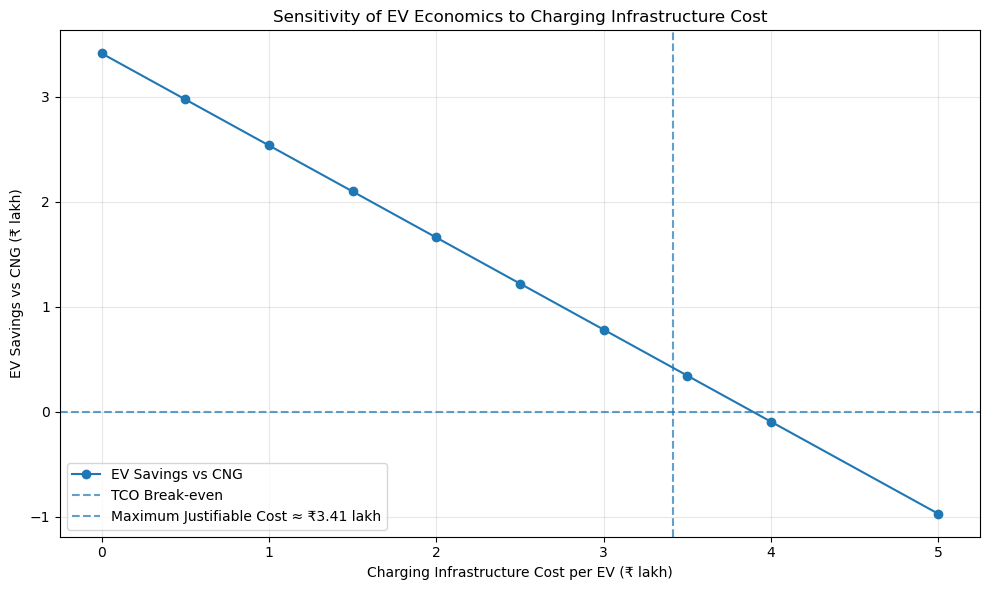

In [134]:
# ============================================================
# PLOT: CHARGING INFRASTRUCTURE SENSITIVITY
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    charging_sensitivity["Charging_Infrastructure_Cost_lakh"],
    charging_sensitivity["EV_Savings_vs_CNG_lakh"],
    marker="o",
    label="EV Savings vs CNG"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.7,
    label="TCO Break-even"
)

plt.axvline(
    max_infrastructure_cost,
    linestyle="--",
    alpha=0.7,
    label=f"Maximum Justifiable Cost ≈ ₹{max_infrastructure_cost:.2f} lakh"
)

plt.xlabel("Charging Infrastructure Cost per EV (₹ lakh)")
plt.ylabel("EV Savings vs CNG (₹ lakh)")
plt.title("Sensitivity of EV Economics to Charging Infrastructure Cost")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [135]:
# ============================================================
# INFRASTRUCTURE BREAK-EVEN SUMMARY
# ============================================================

infrastructure_break_even = pd.DataFrame({
    "Metric": [
        "Baseline EV TCO",
        "Baseline CNG TCO",
        "Baseline EV Advantage vs CNG",
        "Maximum Justifiable Infrastructure Cost"
    ],
    
    "Value_lakh": [
        baseline_ev_tco_lakh,
        baseline_cng_tco_lakh,
        baseline_cng_tco_lakh - baseline_ev_tco_lakh,
        max_infrastructure_cost
    ]
})

infrastructure_break_even

,Metric,Value_lakh
0,Baseline EV TCO,8.175000
1,Baseline CNG TCO,11.587328
2,Baseline EV Advantage vs CNG,3.412329
3,Maximum Justifiable Infrastructure Cost,3.412329


Fleet Economic Analysis

In [136]:
# ============================================================
# FLEET ECONOMIC ANALYSIS
# ============================================================

fleet_sizes = [1, 5, 10, 25, 50]

fleet_data = []

ev_tco_lakh = calculate_tco(
    ev,
    baseline_utilization
) / 100000

cng_tco_lakh = calculate_tco(
    cng,
    baseline_utilization
) / 100000

for n in fleet_sizes:

    total_ev_tco = n * ev_tco_lakh
    total_cng_tco = n * cng_tco_lakh

    total_ev_purchase = n * ev["purchase_price_lakh"]
    total_cng_purchase = n * cng["purchase_price_lakh"]

    fleet_data.append({
        "Fleet_Size": n,
        "EV_Purchase_Investment_lakh": total_ev_purchase,
        "CNG_Purchase_Investment_lakh": total_cng_purchase,
        "EV_5Y_TCO_lakh": total_ev_tco,
        "CNG_5Y_TCO_lakh": total_cng_tco,
        "Fleet_Savings_with_EV_lakh": (
            total_cng_tco - total_ev_tco
        )
    })

fleet_analysis = pd.DataFrame(fleet_data)

fleet_analysis

,Fleet_Size,EV_Purchase_Investment_lakh,CNG_Purchase_Investment_lakh,EV_5Y_TCO_lakh,CNG_5Y_TCO_lakh,Fleet_Savings_with_EV_lakh
0,1,6.5,4.99,8.175000,11.587328,3.412329
1,5,32.5,24.95,40.874997,57.936642,17.061644
2,10,65.0,49.90,81.749995,115.873284,34.123289
3,25,162.5,124.75,204.374988,289.683210,85.308222
4,50,325.0,249.50,408.749975,579.366419,170.616444


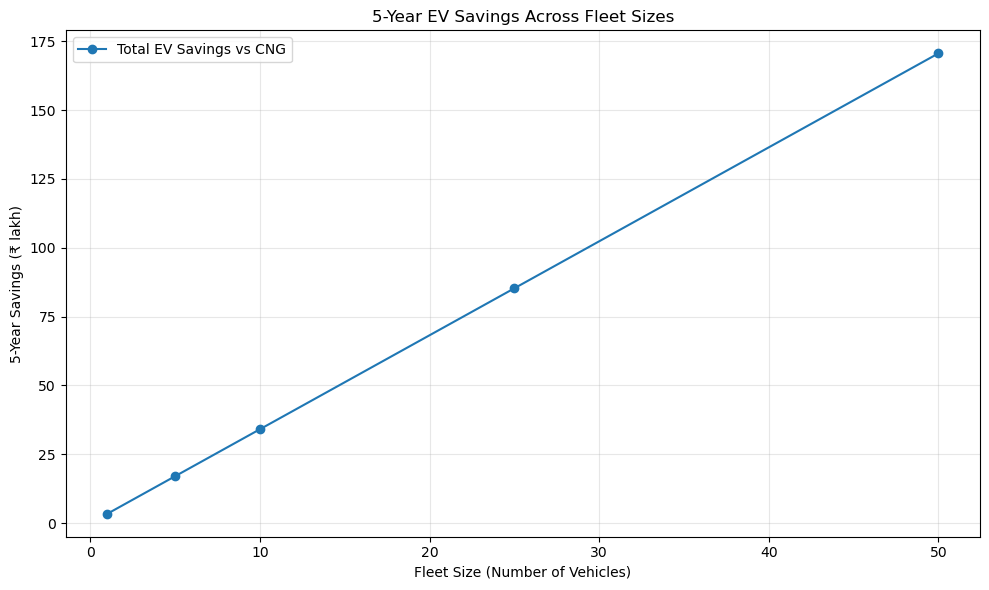

In [137]:
# ============================================================
# FLEET SAVINGS PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    fleet_analysis["Fleet_Size"],
    fleet_analysis["Fleet_Savings_with_EV_lakh"],
    marker="o",
    label="Total EV Savings vs CNG"
)

plt.xlabel("Fleet Size (Number of Vehicles)")
plt.ylabel("5-Year Savings (₹ lakh)")
plt.title("5-Year EV Savings Across Fleet Sizes")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [138]:
# ============================================================
# PAYLOAD SENSITIVITY ANALYSIS
# ============================================================

payload_levels = [250, 400, 500, 600, 750]

payload_sensitivity = []

for payload in payload_levels:

    # Create copies so original vehicle data is unchanged
    modified_ev = ev.copy()
    modified_cng = cng.copy()
    modified_diesel = diesel.copy()

    # Change payload
    modified_ev["payload_kg"] = payload
    modified_cng["payload_kg"] = payload
    modified_diesel["payload_kg"] = payload

    # Calculate TCO
    ev_tco = (
        calculate_tco(
            modified_ev,
            baseline_utilization
        ) / 100000
    )

    cng_tco = (
        calculate_tco(
            modified_cng,
            baseline_utilization
        ) / 100000
    )

    diesel_tco = (
        calculate_tco(
            modified_diesel,
            baseline_utilization
        ) / 100000
    )

    payload_sensitivity.append({
        "Payload_kg": payload,
        "EV_TCO_lakh": ev_tco,
        "CNG_TCO_lakh": cng_tco,
        "Diesel_TCO_lakh": diesel_tco,
        "EV_Savings_vs_CNG_lakh": cng_tco - ev_tco,
        "EV_Savings_vs_Diesel_lakh": diesel_tco - ev_tco
    })

payload_sensitivity = pd.DataFrame(payload_sensitivity)

payload_sensitivity

,Payload_kg,EV_TCO_lakh,CNG_TCO_lakh,Diesel_TCO_lakh,EV_Savings_vs_CNG_lakh,EV_Savings_vs_Diesel_lakh
0,250,8.175,11.587328,13.150645,3.412329,4.975646
1,400,8.175,11.587328,13.150645,3.412329,4.975646
2,500,8.175,11.587328,13.150645,3.412329,4.975646
3,600,8.175,11.587328,13.150645,3.412329,4.975646
4,750,8.175,11.587328,13.150645,3.412329,4.975646


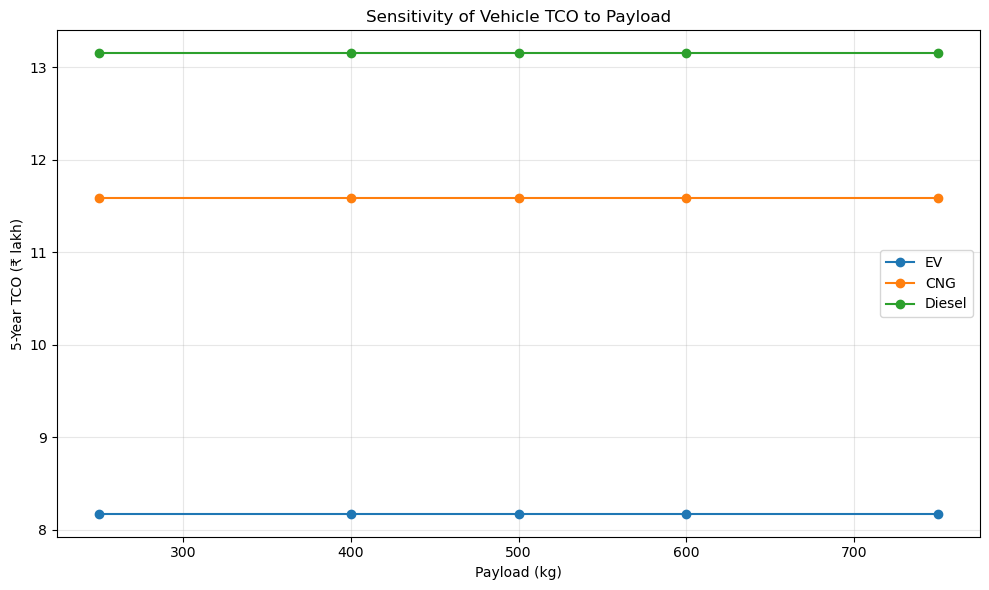

In [139]:
# ============================================================
# PLOT: TCO VS PAYLOAD
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    payload_sensitivity["Payload_kg"],
    payload_sensitivity["EV_TCO_lakh"],
    marker="o",
    label="EV"
)

plt.plot(
    payload_sensitivity["Payload_kg"],
    payload_sensitivity["CNG_TCO_lakh"],
    marker="o",
    label="CNG"
)

plt.plot(
    payload_sensitivity["Payload_kg"],
    payload_sensitivity["Diesel_TCO_lakh"],
    marker="o",
    label="Diesel"
)

plt.xlabel("Payload (kg)")
plt.ylabel("5-Year TCO (₹ lakh)")
plt.title("Sensitivity of Vehicle TCO to Payload")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

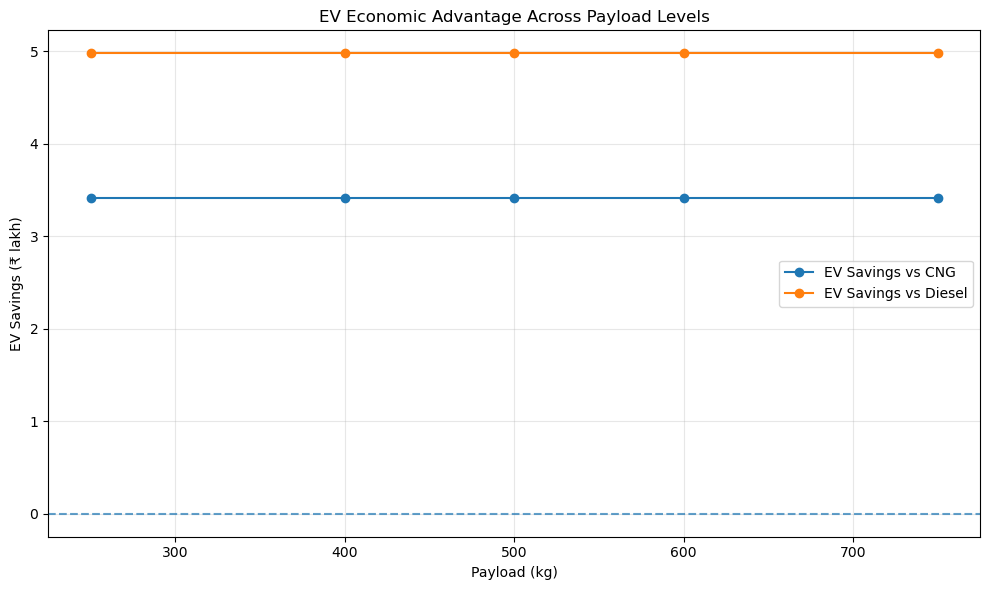

In [140]:
# ============================================================
# PLOT: EV SAVINGS VS PAYLOAD
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    payload_sensitivity["Payload_kg"],
    payload_sensitivity["EV_Savings_vs_CNG_lakh"],
    marker="o",
    label="EV Savings vs CNG"
)

plt.plot(
    payload_sensitivity["Payload_kg"],
    payload_sensitivity["EV_Savings_vs_Diesel_lakh"],
    marker="o",
    label="EV Savings vs Diesel"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.7
)

plt.xlabel("Payload (kg)")
plt.ylabel("EV Savings (₹ lakh)")
plt.title("EV Economic Advantage Across Payload Levels")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [141]:
# ============================================================
# CONSOLIDATED BASELINE RESULTS
# ============================================================

baseline_results = pd.DataFrame({
    "Metric": [
        "Purchase Price",
        "Annual Utilization",
        "Annual Energy Cost",
        "5-Year TCO",
        "TCO Saving vs CNG",
        "TCO Saving vs Diesel"
    ],

    "EV": [
        ev["purchase_price_lakh"],
        baseline_utilization,
        ev["annual_energy_cost"],
        ev["five_year_tco_lakh"],
        cng["five_year_tco_lakh"] - ev["five_year_tco_lakh"],
        diesel["five_year_tco_lakh"] - ev["five_year_tco_lakh"]
    ],

    "CNG": [
        cng["purchase_price_lakh"],
        baseline_utilization,
        cng["annual_energy_cost"],
        cng["five_year_tco_lakh"],
        None,
        None
    ],

    "Diesel": [
        diesel["purchase_price_lakh"],
        baseline_utilization,
        diesel["annual_energy_cost"],
        diesel["five_year_tco_lakh"],
        None,
        None
    ]
})

baseline_results

,Metric,EV,CNG,Diesel
0,Purchase Price,6.500000,4.990000,5.990000
1,Annual Utilization,25000.000000,25000.000000,25000.000000
2,Annual Energy Cost,13500.000000,98916.567750,108182.900000
3,5-Year TCO,8.175000,11.587328,13.150645
4,TCO Saving vs CNG,3.412329,NaN,NaN
5,TCO Saving vs Diesel,4.975646,NaN,NaN


In [142]:
# ============================================================
# PERCENTAGE TCO SAVINGS
# ============================================================

ev_tco = ev["five_year_tco_lakh"]
cng_tco = cng["five_year_tco_lakh"]
diesel_tco = diesel["five_year_tco_lakh"]

saving_vs_cng = cng_tco - ev_tco
saving_vs_diesel = diesel_tco - ev_tco

percentage_saving_vs_cng = (
    saving_vs_cng / cng_tco
) * 100

percentage_saving_vs_diesel = (
    saving_vs_diesel / diesel_tco
) * 100

print(
    f"EV TCO saving vs CNG: "
    f"₹{saving_vs_cng:.3f} lakh "
    f"({percentage_saving_vs_cng:.2f}%)"
)

print(
    f"EV TCO saving vs Diesel: "
    f"₹{saving_vs_diesel:.3f} lakh "
    f"({percentage_saving_vs_diesel:.2f}%)"
)

EV TCO saving vs CNG: ₹3.412 lakh (29.45%)
EV TCO saving vs Diesel: ₹4.976 lakh (37.84%)


In [143]:
# ============================================================

# ============================================================

print("========== MODEL SANITY CHECK ==========")

print(f"Baseline utilization: {baseline_utilization:,} km/year")

print("\n5-Year TCO:")
print(f"EV     : ₹{ev_tco:.3f} lakh")
print(f"CNG    : ₹{cng_tco:.3f} lakh")
print(f"Diesel : ₹{diesel_tco:.3f} lakh")

print("\nEV advantage:")
print(f"Vs CNG    : ₹{saving_vs_cng:.3f} lakh")
print(f"Vs Diesel : ₹{saving_vs_diesel:.3f} lakh")

print("\nBreak-even:")
print(
    f"EV-CNG utilization: "
    f"{break_even_km:,.0f} km/year"
)

print(
    f"Maximum charging infrastructure cost: "
    f"₹{max_infrastructure_cost:.3f} lakh"
)

print("\nPayback:")
print(f"Vs CNG    : {payback_vs_cng:.2f} years")
print(f"Vs Diesel : {payback_vs_diesel:.2f} years")

print("\n========================================")

========== MODEL SANITY CHECK ==========
Baseline utilization: 25,000 km/year

5-Year TCO:
EV     : ₹8.175 lakh
CNG    : ₹11.587 lakh
Diesel : ₹13.151 lakh

EV advantage:
Vs CNG    : ₹3.412 lakh
Vs Diesel : ₹4.976 lakh

Break-even:
EV-CNG utilization: 5,025 km/year
Maximum charging infrastructure cost: ₹3.412 lakh

Payback:
Vs CNG    : 1.77 years
Vs Diesel : 1.59 years



In [144]:
# ============================================================
# SCENARIO ANALYSIS
# ============================================================

scenarios = {
    "Low Utilization": 10_000,
    "Base Case": 25_000,
    "High Utilization": 50_000
}

scenario_results = []

for scenario, annual_km in scenarios.items():

    # Calculate five-year TCO for each vehicle
    ev_tco = calculate_tco(ev, annual_km) / 100000
    cng_tco = calculate_tco(cng, annual_km) / 100000
    diesel_tco = calculate_tco(diesel, annual_km) / 100000

    scenario_results.append({
        "Scenario": scenario,
        "Annual_Utilization_km": annual_km,
        "EV_TCO_lakh": ev_tco,
        "CNG_TCO_lakh": cng_tco,
        "Diesel_TCO_lakh": diesel_tco,
        "EV_Saving_vs_CNG_lakh": cng_tco - ev_tco,
        "EV_Saving_vs_Diesel_lakh": diesel_tco - ev_tco
    })

scenario_results = pd.DataFrame(scenario_results)

scenario_results

,Scenario,Annual_Utilization_km,EV_TCO_lakh,CNG_TCO_lakh,Diesel_TCO_lakh,EV_Saving_vs_CNG_lakh,EV_Saving_vs_Diesel_lakh
0,Low Utilization,10000,7.769999,8.619831,9.905158,0.849832,2.135159
1,Base Case,25000,8.175000,11.587328,13.150645,3.412329,4.975646
2,High Utilization,50000,8.849999,16.533157,18.559790,7.683157,9.709791


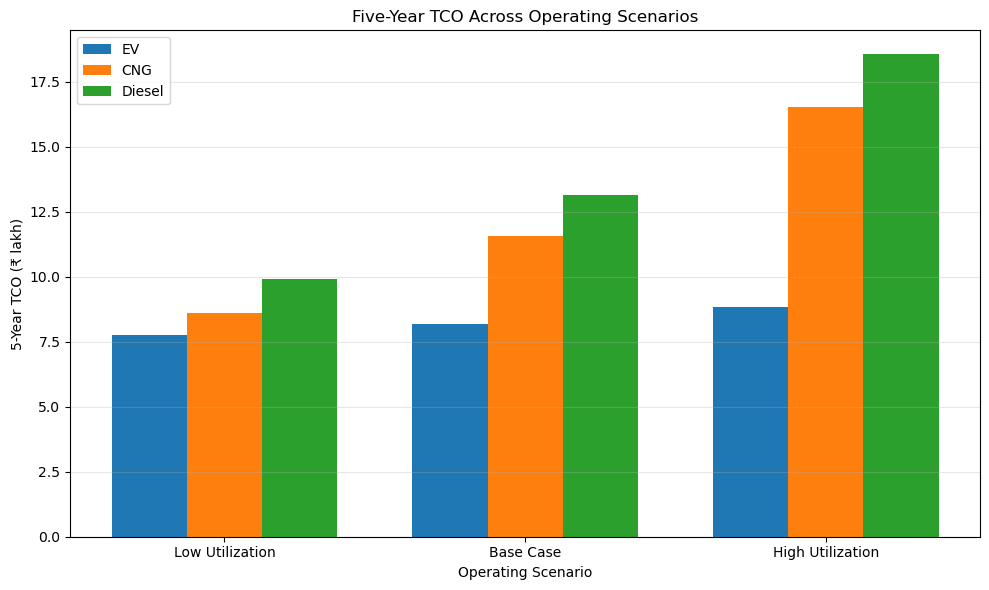

In [145]:
# ============================================================
# SCENARIO TCO COMPARISON
# ============================================================

x = np.arange(len(scenario_results))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(
    x - width,
    scenario_results["EV_TCO_lakh"],
    width,
    label="EV"
)

plt.bar(
    x,
    scenario_results["CNG_TCO_lakh"],
    width,
    label="CNG"
)

plt.bar(
    x + width,
    scenario_results["Diesel_TCO_lakh"],
    width,
    label="Diesel"
)

plt.xticks(
    x,
    scenario_results["Scenario"]
)

plt.ylabel("5-Year TCO (₹ lakh)")
plt.xlabel("Operating Scenario")
plt.title("Five-Year TCO Across Operating Scenarios")

plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [146]:
# ============================================================
# IDENTIFY LOWEST-COST TECHNOLOGY BY SCENARIO
# ============================================================

scenario_results["Lowest_TCO"] = (
    scenario_results[
        ["EV_TCO_lakh", "CNG_TCO_lakh", "Diesel_TCO_lakh"]
    ]
    .idxmin(axis=1)
    .str.replace("_TCO_lakh", "")
)

scenario_results[
    [
        "Scenario",
        "Annual_Utilization_km",
        "Lowest_TCO"
    ]
]

,Scenario,Annual_Utilization_km,Lowest_TCO
0,Low Utilization,10000,EV
1,Base Case,25000,EV
2,High Utilization,50000,EV


In [147]:
# ============================================================
# SIMPLE FLEET DECISION MATRIX
# ============================================================

decision_matrix = scenario_results[
    [
        "Scenario",
        "Annual_Utilization_km",
        "EV_TCO_lakh",
        "CNG_TCO_lakh",
        "Diesel_TCO_lakh",
        "Lowest_TCO"
    ]
].copy()

decision_matrix

,Scenario,Annual_Utilization_km,EV_TCO_lakh,CNG_TCO_lakh,Diesel_TCO_lakh,Lowest_TCO
0,Low Utilization,10000,7.769999,8.619831,9.905158,EV
1,Base Case,25000,8.175000,11.587328,13.150645,EV
2,High Utilization,50000,8.849999,16.533157,18.559790,EV


In [148]:
# ============================================================
# KEY PROJECT METRICS
# ============================================================

key_metrics = {
    "EV 5-Year TCO (₹ lakh)": ev["five_year_tco_lakh"],
    "EV Saving vs CNG (₹ lakh)": saving_vs_cng,
    "EV Saving vs Diesel (₹ lakh)": saving_vs_diesel,
    "EV-CNG Break-even (km/year)": break_even_km,
    "Maximum Infrastructure Cost (₹ lakh)": max_infrastructure_cost
}

for metric, value in key_metrics.items():
    print(f"{metric}: {value:.3f}")

EV 5-Year TCO (₹ lakh): 8.175
EV Saving vs CNG (₹ lakh): 3.412
EV Saving vs Diesel (₹ lakh): 4.976
EV-CNG Break-even (km/year): 5025.369
Maximum Infrastructure Cost (₹ lakh): 3.412


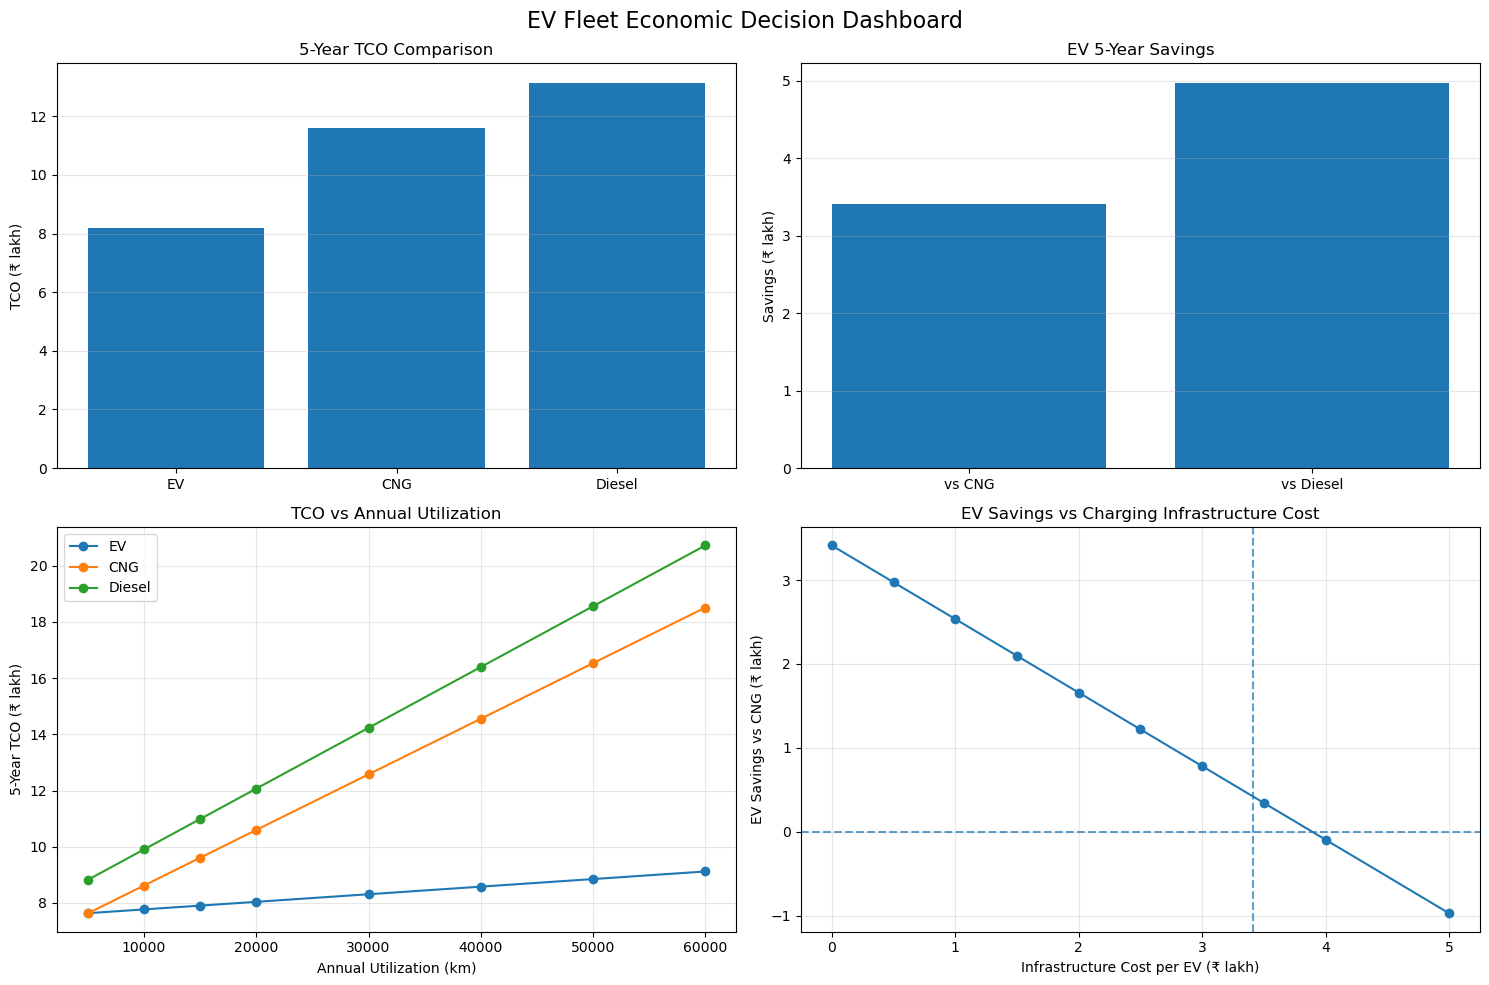

In [149]:

# FINAL DECISION DASHBOARD
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))


# ------------------------------------------------------------
# 1. BASELINE TCO COMPARISON
# ------------------------------------------------------------

vehicles_names = ["EV", "CNG", "Diesel"]

tco_values = [
    ev["five_year_tco_lakh"],
    cng["five_year_tco_lakh"],
    diesel["five_year_tco_lakh"]
]

axes[0, 0].bar(
    vehicles_names,
    tco_values
)

axes[0, 0].set_title("5-Year TCO Comparison")
axes[0, 0].set_ylabel("TCO (₹ lakh)")
axes[0, 0].grid(
    axis="y",
    alpha=0.3
)


# ------------------------------------------------------------
# 2. EV SAVINGS
# ------------------------------------------------------------

comparison_names = ["vs CNG", "vs Diesel"]

savings_values = [
    saving_vs_cng,
    saving_vs_diesel
]

axes[0, 1].bar(
    comparison_names,
    savings_values
)

axes[0, 1].set_title("EV 5-Year Savings")
axes[0, 1].set_ylabel("Savings (₹ lakh)")
axes[0, 1].grid(
    axis="y",
    alpha=0.3
)


# ------------------------------------------------------------
# 3. TCO VS ANNUAL UTILIZATION
# ------------------------------------------------------------

axes[1, 0].plot(
    utilization_sensitivity["Annual_Utilization_km"],
    utilization_sensitivity["EV_TCO_lakh"],
    marker="o",
    label="EV"
)

axes[1, 0].plot(
    utilization_sensitivity["Annual_Utilization_km"],
    utilization_sensitivity["CNG_TCO_lakh"],
    marker="o",
    label="CNG"
)

axes[1, 0].plot(
    utilization_sensitivity["Annual_Utilization_km"],
    utilization_sensitivity["Diesel_TCO_lakh"],
    marker="o",
    label="Diesel"
)

axes[1, 0].set_title("TCO vs Annual Utilization")
axes[1, 0].set_xlabel("Annual Utilization (km)")
axes[1, 0].set_ylabel("5-Year TCO (₹ lakh)")
axes[1, 0].legend()
axes[1, 0].grid(
    alpha=0.3
)


# ------------------------------------------------------------
# 4. INFRASTRUCTURE COST SENSITIVITY
# ------------------------------------------------------------

axes[1, 1].plot(
    charging_sensitivity[
        "Charging_Infrastructure_Cost_lakh"
    ],
    charging_sensitivity[
        "EV_Savings_vs_CNG_lakh"
    ],
    marker="o"
)

axes[1, 1].axhline(
    0,
    linestyle="--",
    alpha=0.7
)

axes[1, 1].axvline(
    max_infrastructure_cost,
    linestyle="--",
    alpha=0.7
)

axes[1, 1].set_title(
    "EV Savings vs Charging Infrastructure Cost"
)

axes[1, 1].set_xlabel(
    "Infrastructure Cost per EV (₹ lakh)"
)

axes[1, 1].set_ylabel(
    "EV Savings vs CNG (₹ lakh)"
)

axes[1, 1].grid(
    alpha=0.3
)


# ------------------------------------------------------------
# FINAL LAYOUT
# ------------------------------------------------------------

fig.suptitle(
    "EV Fleet Economic Decision Dashboard",
    fontsize=16
)

plt.tight_layout()

plt.show()

## Key Findings

### 1. EV has the lowest baseline TCO

Under the baseline assumptions, the EV achieves the lowest five-year TCO among the three vehicle technologies.

### 2. Higher utilization improves EV economics

The utilization sensitivity analysis shows that the economic advantage of the EV increases with annual distance travelled. This occurs because the EV benefits from lower energy costs per kilometre.

### 3. Purchase price remains an important factor

Increasing the EV purchase price directly increases its five-year TCO and reduces its economic advantage over conventional alternatives.

### 4. Energy prices influence the relative economics

Changes in electricity, CNG and diesel prices affect the comparative TCO. The sensitivity analysis demonstrates that energy-price assumptions should therefore be considered when evaluating fleet electrification.

### 5. Charging infrastructure is an important adoption consideration

Additional charging infrastructure expenditure reduces the EV's economic advantage. However, under the baseline assumptions, the EV can absorb a substantial additional infrastructure cost while retaining a TCO advantage over CNG.

### 6. Fleet-scale adoption increases the absolute economic benefit

Although the per-vehicle economics remain the same under the linear fleet assumption, total savings increase with fleet size. This makes fleet electrification particularly relevant for high-utilization commercial operators.

### 7. Utilization should be considered when making fleet decisions

The results indicate that annual vehicle utilization is one of the most important factors affecting the economic case for EV adoption. High-utilization applications are generally more favorable for electrification because lower operating costs are realized over more kilometres.